Dataset Features Shape: (178, 13)
Target Wine Classes: ['class_0' 'class_1' 'class_2'] (represented as integers 0, 1, 2)

Training samples: 142
Testing samples: 36

Training Random Forest Pipeline model...

        WINE CLASSIFICATION METRICS REPORT
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Generating visual Confusion Matrix plot...


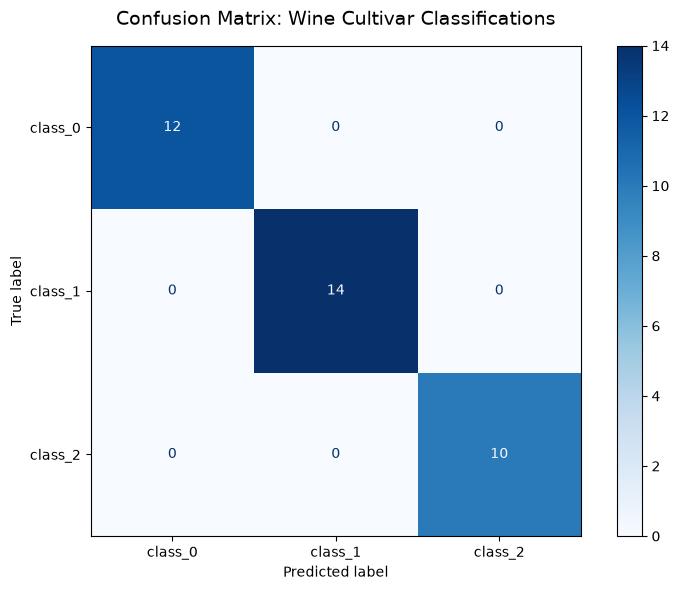

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# 1. Load the classic wine dataset 
wine_data = load_wine()
X = wine_data.data
y = wine_data.target
feature_names = wine_data.feature_names
target_names = wine_data.target_names
    
print(f"Dataset Features Shape: {X.shape}")
print(f"Target Wine Classes: {target_names} (represented as integers 0, 1, 2)\n")

# split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}\n")


#  pipeline 

wine_pipeline = Pipeline([('scaler', StandardScaler()), ('random_forest', RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42))])

print("Training Random Forest Pipeline model...")
wine_pipeline.fit(X_train, y_train)

# predic

y_pred = wine_pipeline.predict(X_test)

print("\n" + "="*50)
print("        WINE CLASSIFICATION METRICS REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=target_names))
print("="*50 + "\n")

print("Generating visual Confusion Matrix plot...")
    
# We create the plot figure manually to manage size cleanly
fig, ax = plt.subplots(figsize=(8, 6))
    
# Draw the matrix directly from the trained pipeline estimator
ConfusionMatrixDisplay.from_estimator(
        estimator=wine_pipeline,
        X=X_test,
        y=y_test,
        display_labels=target_names,
        cmap='Blues',
        ax=ax
)
    
# Polish the layout aesthetics
plt.title("Confusion Matrix: Wine Cultivar Classifications", fontsize=14, pad=15)
plt.tight_layout()
    
# Show the plot
plt.show()

Loading Wine Quality Dataset...
Dataset Features Shape: (178, 13)
Target Wine Classes: ['class_0' 'class_1' 'class_2'] (represented as integers 0, 1, 2)

Training samples: 142
Testing samples: 36

Training Random Forest Pipeline model...

        WINE CLASSIFICATION METRICS REPORT
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Generating visual Confusion Matrix plot...


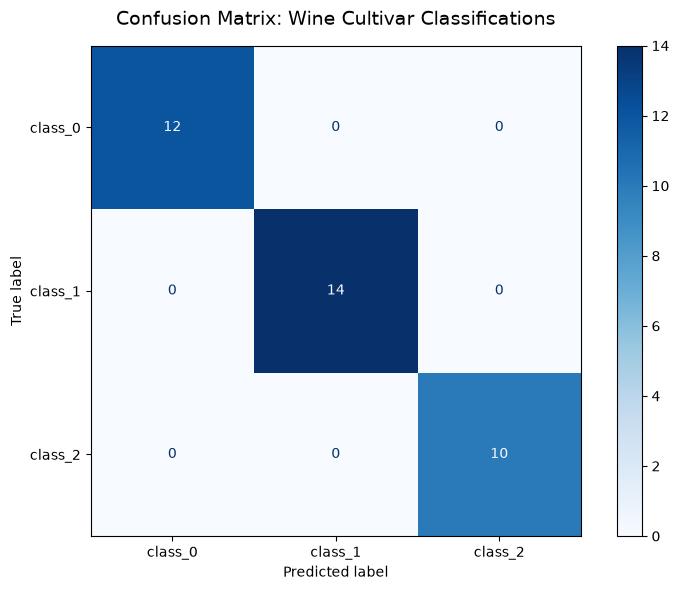

In [7]:
# =====================================================================
# Week 3 Milestone: Wine Quality Classification Pipeline
# File: 04_week3_milestone.py (or copy into 04_week3_milestone.ipynb)
# =====================================================================

import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

def run_milestone_pipeline():
    # -----------------------------------------------------------------
    # Step 1: Load Scikit-Learn's Native Wine Dataset
    # -----------------------------------------------------------------
    print("Loading Wine Quality Dataset...")
    wine_data = load_wine()
    X = wine_data.data
    y = wine_data.target
    feature_names = wine_data.feature_names
    target_names = wine_data.target_names
    
    print(f"Dataset Features Shape: {X.shape}")
    print(f"Target Wine Classes: {target_names} (represented as integers 0, 1, 2)\n")

    # -----------------------------------------------------------------
    # Step 2: Perform 80/20 Stratified Partition Split
    # -----------------------------------------------------------------
    # Stratification keeps our class distributions identical in train and test splits
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y
    )
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}\n")

    # -----------------------------------------------------------------
    # Step 3: Build a Unified Scikit-Learn Preprocessing & Estimator Pipeline
    # -----------------------------------------------------------------
    # Although Random Forests are invariant to feature scaling, standardizing is a
    # best-practice default pipeline structure for modular expansion (e.g., if we swap models)
    wine_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('random_forest', RandomForestClassifier(
            n_estimators=100, 
            max_depth=5, 
            random_state=42
        ))
    ])

    # -----------------------------------------------------------------
    # Step 4: Fit (Train) the Integrated Pipeline Model
    # -----------------------------------------------------------------
    print("Training Random Forest Pipeline model...")
    wine_pipeline.fit(X_train, y_train)

    # -----------------------------------------------------------------
    # Step 5: Evaluate the Predictions
    # -----------------------------------------------------------------
    y_pred = wine_pipeline.predict(X_test)
    
    print("\n" + "="*50)
    print("        WINE CLASSIFICATION METRICS REPORT")
    print("="*50)
    print(classification_report(y_test, y_pred, target_names=target_names))
    print("="*50 + "\n")

    # -----------------------------------------------------------------
    # Step 6: Generate and Show a Clean Confusion Matrix Plot
    # -----------------------------------------------------------------
    print("Generating visual Confusion Matrix plot...")
    
    # We create the plot figure manually to manage size cleanly
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Draw the matrix directly from the trained pipeline estimator
    ConfusionMatrixDisplay.from_estimator(
        estimator=wine_pipeline,
        X=X_test,
        y=y_test,
        display_labels=target_names,
        cmap='Blues',
        ax=ax
    )
    
    # Polish the layout aesthetics
    plt.title("Confusion Matrix: Wine Cultivar Classifications", fontsize=14, pad=15)
    plt.tight_layout()
    
    # Show the plot
    plt.show()

if __name__ == "__main__":
    run_milestone_pipeline()